# Resultados da ablação — sMCI vs pMCI

Pipeline de visualização para apresentação e artigo.

**Entrada:** `ablation_summary_*.csv` e `ablation_results_*.csv` em `csvs/abordagem_4_sMCI_pMCI_extremos/`

**Saída:** figuras PNG (300 dpi) e PDF em `csvs/abordagem_4_sMCI_pMCI_extremos/figures/`

**Protocolo:** nested CV 5×5, seleção MRMR por bloco (corr + var + MRMR), modelos SVM / RF / MLP.

In [65]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# ── Configuração ─────────────────────────────────────────────────────────────

BASE_DIR = Path("csvs/abordagem_4_sMCI_pMCI_extremos")
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["svm", "rf", "mlp"]
MODEL_LABELS = {"svm": "SVM", "rf": "Random Forest", "mlp": "MLP"}
FAMILY_ORDER = ["volume", "rad", "disp", "merge"]
FAMILY_LABELS = {
    "volume": "Volume",
    "rad": "Radiomics",
    "disp": "Displacement",
    "merge": "Merge (rad + disp)",
}
METRICS = ["auc", "f1_pMCI", "mcc", "bal_acc", "auc_pr"]
METRIC_LABELS = {
    "auc": "AUC-ROC",
    "auc_pr": "AUC-PR",
    "f1_pMCI": "F1 (pMCI)",
    "mcc": "MCC",
    "bal_acc": "Balanced accuracy",
}

# Estilo publicação
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)

CHANCE = 0.5
PALETTE_FAMILY = {
    "volume": "#4477AA",
    "rad": "#EE6677",
    "disp": "#228833",
    "merge": "#CC6677",
}
PALETTE_TEMPORAL = {"static": "#4477AA", "delta": "#CCBB44"}

# Cores fixas (paleta colorblind) — hex para legenda e barras iguais
MODEL_COLORS = {
    "svm": "#0173B2",  # azul
    "rf": "#DE8F05",   # amarelo/laranja
    "mlp": "#029E73",  # verde
}


def model_legend(ax, *, loc="upper right", **kwargs) -> None:
    """
    Legenda com quadrados coloridos alinhados às barras.
    NÃO usar ax.legend(labels=[...]) sem handles — gera linhas pretas.
    """
    from matplotlib.patches import Patch

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    def _artist_color(container) -> tuple | str | None:
        """BarContainer → .patches | BoxPlotContainer → .boxes"""
        for attr in ("patches", "boxes"):
            artists = getattr(container, attr, None)
            if artists:
                return artists[0].get_facecolor()
        return None

    handles = []
    for i, m in enumerate(MODEL_ORDER):
        color = MODEL_COLORS[m]
        if getattr(ax, "containers", None) and i < len(ax.containers):
            c = _artist_color(ax.containers[i])
            if c is not None:
                color = c
        handles.append(
            Patch(
                facecolor=color,
                edgecolor="#333333",
                linewidth=0.4,
                label=MODEL_LABELS[m],
            )
        )

    ax.legend(
        handles=handles,
        loc=loc,
        handlelength=1.4,
        handleheight=1.0,
        frameon=True,
        **kwargs,
    )


def save_fig(fig: plt.Figure, name: str) -> None:
    """Salva PNG + PDF com o mesmo nome base."""
    for ext in ("png", "pdf"):
        path = FIG_DIR / f"{name}.{ext}"
        fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {FIG_DIR / name}.[png|pdf]")

In [66]:
def parse_experiment_id(stem: str) -> dict:
    """
    stem = 'onlyvolume_delta_filtered' (sem prefixo ablation_summary_)
    """
    rest = stem.removeprefix("only")
    parts = rest.split("_")
    family = parts[0]
    temporal = "delta" if "delta" in parts else "static"
    filtered = "filtered" in parts

    label_parts = [FAMILY_LABELS.get(family, family.capitalize())]
    if temporal == "delta":
        label_parts.append("Δ")
    if filtered:
        label_parts.append("(filt.)")
    short = " ".join(label_parts)

    return {
        "experiment_id": stem,
        "family": family,
        "temporal": temporal,
        "filtered": filtered,
        "label": short,
        "label_long": f"{FAMILY_LABELS.get(family, family)} — "
        f"{'delta' if temporal == 'delta' else 'estático'}"
        f"{', filtrado' if filtered else ''}",
    }


def load_ablation_results(base_dir: Path = BASE_DIR) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Carrega e concatena todos os CSVs de ablação disponíveis."""
    summary_frames, result_frames = [], []

    for path in sorted(base_dir.glob("ablation_summary_*.csv")):
        exp_id = path.stem.removeprefix("ablation_summary_")
        meta = parse_experiment_id(exp_id)
        df = pd.read_csv(path)
        df = df.assign(**meta, source_summary=path.name)
        summary_frames.append(df)

    for path in sorted(base_dir.glob("ablation_results_*.csv")):
        exp_id = path.stem.removeprefix("ablation_results_")
        meta = parse_experiment_id(exp_id)
        df = pd.read_csv(path)
        df = df.assign(**meta, source_results=path.name)
        result_frames.append(df)

    if not summary_frames:
        raise FileNotFoundError(f"Nenhum ablation_summary_*.csv em {base_dir}")

    summary = pd.concat(summary_frames, ignore_index=True)
    summary["model_key"] = pd.Categorical(
        summary["model_key"], categories=MODEL_ORDER, ordered=True
    )

    results = (
        pd.concat(result_frames, ignore_index=True)
        if result_frames
        else pd.DataFrame()
    )
    if not results.empty:
        results["model_key"] = pd.Categorical(
            results["model_key"], categories=MODEL_ORDER, ordered=True
        )

    return summary, results


summary, results = load_ablation_results()
print(f"Experimentos: {summary['experiment_id'].nunique()}")
print(f"Linhas summary: {len(summary)} | results: {len(results)}")

# Ordenar ANTES de selecionar colunas (family não entra no subset)
_preview = summary.sort_values(["family", "temporal", "filtered", "model_key"])
_preview[["experiment_id", "label", "model_key", "auc_mean", "f1_pMCI_mean"]]

Experimentos: 11
Linhas summary: 33 | results: 165


,experiment_id,label,model_key,auc_mean,f1_pMCI_mean
9,onlydisp_delta,Displacement Δ,svm,0.689303,0.466235
10,onlydisp_delta,Displacement Δ,rf,0.637094,0.389867
11,onlydisp_delta,Displacement Δ,mlp,0.569132,0.329792
13,onlydisp_delta_filtered,Displacement Δ (filt.),svm,0.509826,0.074659
12,onlydisp_delta_filtered,Displacement Δ (filt.),rf,0.575936,0.387081
14,onlydisp_delta_filtered,Displacement Δ (filt.),mlp,0.405738,0.121144
8,onlydisp,Displacement,svm,0.649941,0.416116
6,onlydisp,Displacement,rf,0.724375,0.511610
7,onlydisp,Displacement,mlp,0.696527,0.480214
16,onlydisp_filtered,Displacement (filt.),svm,0.632666,0.416914


In [67]:
# ── Tabela consolidada (artigo / orientador) ──────────────────────────────────

def best_per_experiment(df: pd.DataFrame, metric: str = "auc_mean") -> pd.DataFrame:
    idx = df.groupby("experiment_id")[metric].idxmax()
    best = df.loc[idx].copy()
    order_map = {f: i for i, f in enumerate(FAMILY_ORDER)}
    best["_ord"] = (
        best["family"].map(order_map) * 4
        + best["temporal"].map({"static": 0, "delta": 1})
        + best["filtered"].astype(int)
    )
    return best.sort_values("_ord").drop(columns="_ord")


def export_tables(summary: pd.DataFrame) -> pd.DataFrame:
    best = best_per_experiment(summary)

    table = best[[
        "label", "model_key", "n_features_mean",
        "auc_mean", "auc_std", "auc_pr_mean",
        "f1_pMCI_mean", "f1_pMCI_std",
        "mcc_mean", "bal_acc_mean",
        "sens_pMCI_mean", "spec_sMCI_mean",
    ]].copy()
    table.columns = [
        "Experimento", "Modelo", "N feats",
        "AUC", "AUC SD", "AUC-PR",
        "F1 pMCI", "F1 SD", "MCC", "Bal. Acc",
        "Sens. pMCI", "Esp. sMCI",
    ]
    table["Modelo"] = table["Modelo"].map(MODEL_LABELS)
    table = table.round(3)

    out_csv = BASE_DIR / "ablation_table_best_per_experiment.csv"
    table.to_csv(out_csv, index=False)
    print(f"Tabela salva: {out_csv}")
    display(table)

    # LaTeX (copiar para o artigo)
    latex = table.to_latex(index=False, escape=False, column_format="l" + "c" * (len(table.columns) - 1))
    latex_path = BASE_DIR / "ablation_table_best_per_experiment.tex"
    latex_path.write_text(latex, encoding="utf-8")
    print(f"LaTeX salvo: {latex_path}")
    return table


article_table = export_tables(summary)

Tabela salva: csvs/abordagem_4_sMCI_pMCI_extremos/ablation_table_best_per_experiment.csv


,Experimento,Modelo,N feats,AUC,AUC SD,AUC-PR,F1 pMCI,F1 SD,MCC,Bal. Acc,Sens. pMCI,Esp. sMCI
27,Volume,SVM,13.6,0.768,0.060,0.540,0.525,0.044,0.347,0.695,0.674,0.716
30,Volume Δ,Random Forest,10.0,0.634,0.046,0.373,0.416,0.042,0.156,0.583,0.741,0.425
18,Radiomics,Random Forest,24.0,0.760,0.066,0.532,0.516,0.093,0.333,0.692,0.806,0.577
24,Radiomics (filt.),SVM,12.0,0.767,0.042,0.559,0.505,0.044,0.316,0.679,0.752,0.605
21,Radiomics Δ,Random Forest,10.0,0.563,0.040,0.308,0.359,0.068,0.070,0.536,0.594,0.478
6,Displacement,Random Forest,19.2,0.724,0.065,0.475,0.512,0.066,0.318,0.677,0.688,0.665
15,Displacement (filt.),Random Forest,33.4,0.654,0.082,0.418,0.449,0.055,0.218,0.624,0.654,0.594
9,Displacement Δ,SVM,10.0,0.689,0.083,0.468,0.466,0.117,0.252,0.638,0.586,0.690
12,Displacement Δ (filt.),Random Forest,10.0,0.576,0.051,0.308,0.387,0.035,0.094,0.554,0.610,0.499
0,Merge,SVM,21.6,0.760,0.049,0.553,0.498,0.064,0.310,0.670,0.642,0.698


LaTeX salvo: csvs/abordagem_4_sMCI_pMCI_extremos/ablation_table_best_per_experiment.tex


/mnt/study-data/pgirardi/tmp/ipykernel_2494307/3031108687.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = summary.pivot_table(


Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig01_heatmap_auc.[png|pdf]


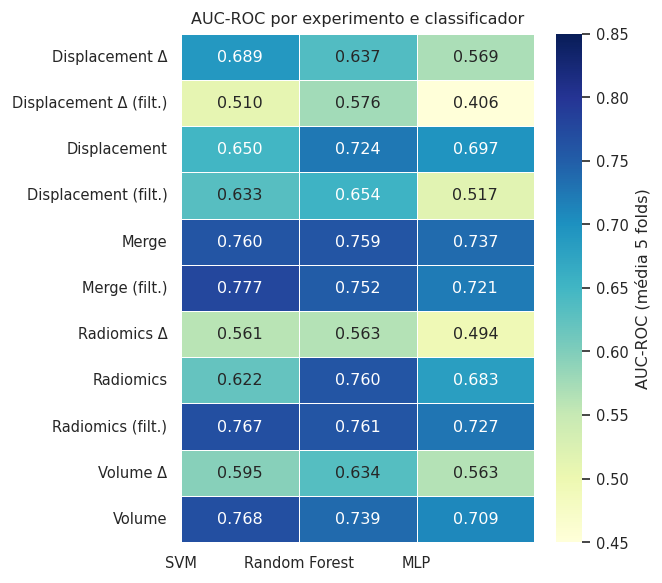

In [68]:
# ── Fig 1: Heatmap AUC — experimentos × modelos ───────────────────────────────

def plot_heatmap_auc(summary: pd.DataFrame) -> plt.Figure:
    pivot = summary.pivot_table(
        index="label", columns="model_key", values="auc_mean", sort=False
    )
    pivot = pivot.reindex(columns=MODEL_ORDER)
    # ordenar linhas por família
    order = (
        summary.drop_duplicates("experiment_id")
        .sort_values(["family", "temporal", "filtered"])["label"]
        .tolist()
    )
    pivot = pivot.reindex([l for l in order if l in pivot.index])

    fig, ax = plt.subplots(figsize=(5.5, max(3, 0.45 * len(pivot))))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="YlGnBu",
        vmin=0.45, vmax=0.85, linewidths=0.5, ax=ax,
        cbar_kws={"label": "AUC-ROC (média 5 folds)"},
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("AUC-ROC por experimento e classificador")
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
    fig.tight_layout()
    return fig


fig1 = plot_heatmap_auc(summary)
save_fig(fig1, "fig01_heatmap_auc")
plt.show()

Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig02_best_auc_per_experiment.[png|pdf]


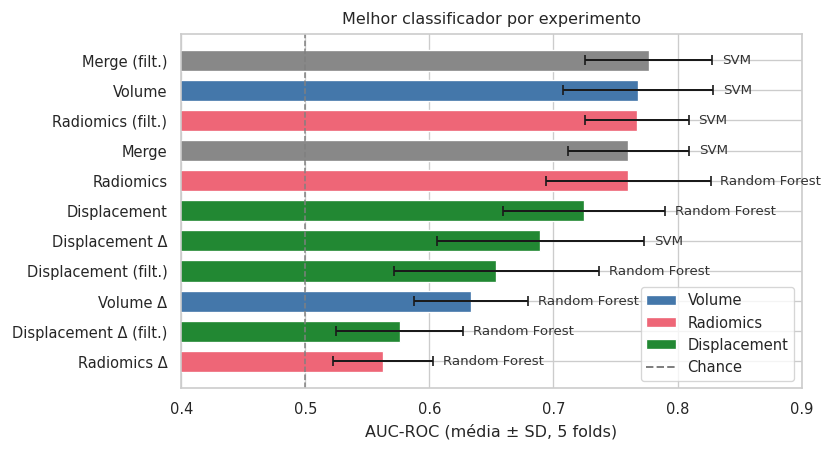

In [69]:
# ── Fig 2: Melhor AUC por experimento (barras com erro) ───────────────────────

def plot_best_auc_bars(summary: pd.DataFrame) -> plt.Figure:
    best = best_per_experiment(summary)
    best = best.sort_values("auc_mean", ascending=True)

    fig, ax = plt.subplots(figsize=(7, max(3.5, 0.35 * len(best))))
    colors = [PALETTE_FAMILY.get(f, "#888888") for f in best["family"]]
    bars = ax.barh(
        best["label"], best["auc_mean"], xerr=best["auc_std"],
        color=colors, capsize=3, edgecolor="white", height=0.7,
    )
    ax.axvline(CHANCE, color="gray", ls="--", lw=0.9, label="Chance (0.5)")
    ax.set_xlim(0.4, 0.9)
    ax.set_xlabel("AUC-ROC (média ± SD, 5 folds)")
    ax.set_title("Melhor classificador por experimento")

    for i, row in enumerate(best.itertuples()):
        ax.text(
            row.auc_mean + row.auc_std + 0.008, i,
            f"{MODEL_LABELS[row.model_key]}",
            va="center", fontsize=8, color="#333333",
        )

    from matplotlib.patches import Patch
    legend_fam = [Patch(facecolor=PALETTE_FAMILY[f], label=FAMILY_LABELS[f]) for f in FAMILY_ORDER if f in best["family"].values]
    ax.legend(handles=legend_fam + [plt.Line2D([0], [0], color="gray", ls="--", label="Chance")],
              loc="lower right", frameon=True)
    fig.tight_layout()
    return fig


fig2 = plot_best_auc_bars(summary)
save_fig(fig2, "fig02_best_auc_per_experiment")
plt.show()

/mnt/study-data/pgirardi/tmp/ipykernel_2494307/963922989.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig03_models_per_experiment.[png|pdf]


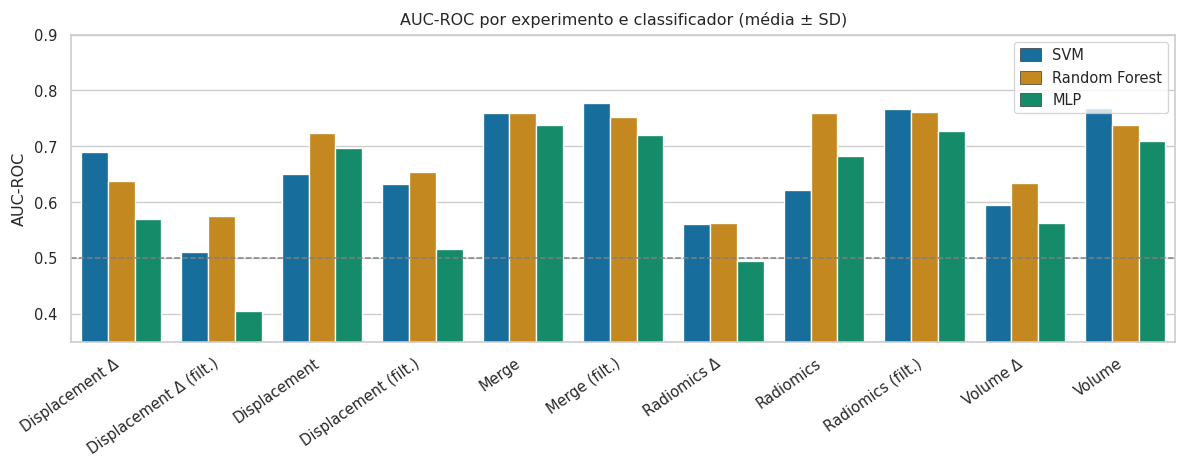

In [70]:
# ── Fig 3: Comparação por modelo (todos os experimentos) ──────────────────────

def plot_models_all_experiments(summary: pd.DataFrame) -> plt.Figure:
    plot_df = summary.copy()
    exp_order = (
        plot_df.drop_duplicates("experiment_id")
        .sort_values(["family", "temporal", "filtered"])["label"]
        .tolist()
    )
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=exp_order, ordered=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(
        data=plot_df, x="label", y="auc_mean", hue="model_key",
        hue_order=MODEL_ORDER, palette=MODEL_COLORS,
        edgecolor="white", capsize=0.08, errorbar=("sd", 1),
        err_kws={"color": "#333333"}, ax=ax, legend=False,
    )
    ax.axhline(CHANCE, color="gray", ls="--", lw=0.9)
    ax.set_ylabel("AUC-ROC")
    ax.set_xlabel("")
    ax.set_title("AUC-ROC por experimento e classificador (média ± SD)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    model_legend(ax, loc="upper right")  # requer célula 1 com MODEL_COLORS / model_legend
    ax.set_ylim(0.35, 0.9)
    fig.tight_layout()
    return fig


# Kernel → Restart & Run All (célula 1 antes desta)
fig3 = plot_models_all_experiments(summary)
save_fig(fig3, "fig03_models_per_experiment")
plt.show()

Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig04_static_vs_delta.[png|pdf]


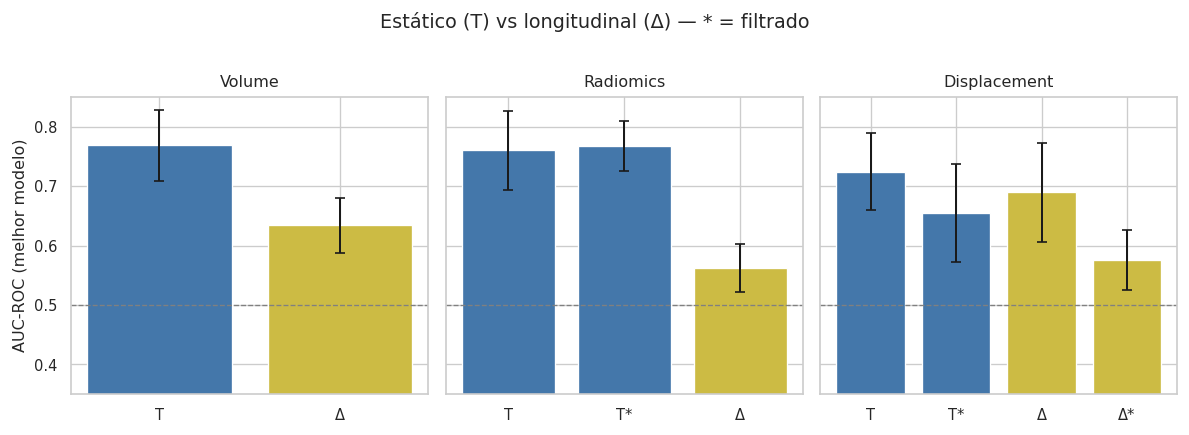

In [71]:
# ── Fig 4: Estático vs Delta (melhor modelo por família) ──────────────────────

def plot_static_vs_delta(summary: pd.DataFrame) -> plt.Figure:
    best = best_per_experiment(summary)
    sub = best[best["family"].isin(FAMILY_ORDER)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)
    for ax, family in zip(axes, FAMILY_ORDER):
        fam = sub[sub["family"] == family]
        if fam.empty:
            ax.set_visible(False)
            continue

        x_labels, aucs, errs, colors = [], [], [], []
        for temporal in ("static", "delta"):
            for filtered in (False, True):
                row = fam[(fam["temporal"] == temporal) & (fam["filtered"] == filtered)]
                if row.empty:
                    continue
                r = row.iloc[0]
                tag = ("Δ" if temporal == "delta" else "T") + ("*" if filtered else "")
                x_labels.append(tag)
                aucs.append(r["auc_mean"])
                errs.append(r["auc_std"])
                colors.append(PALETTE_TEMPORAL[temporal])

        ax.bar(x_labels, aucs, yerr=errs, capsize=3, color=colors, edgecolor="white")
        ax.axhline(CHANCE, color="gray", ls="--", lw=0.8)
        ax.set_title(FAMILY_LABELS[family])
        ax.set_ylim(0.35, 0.85)
        if family == FAMILY_ORDER[0]:
            ax.set_ylabel("AUC-ROC (melhor modelo)")

    fig.suptitle("Estático (T) vs longitudinal (Δ) — * = filtrado", y=1.02)
    fig.tight_layout()
    return fig


fig4 = plot_static_vs_delta(summary)
save_fig(fig4, "fig04_static_vs_delta")
plt.show()

Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig05_fold_boxplots.[png|pdf]


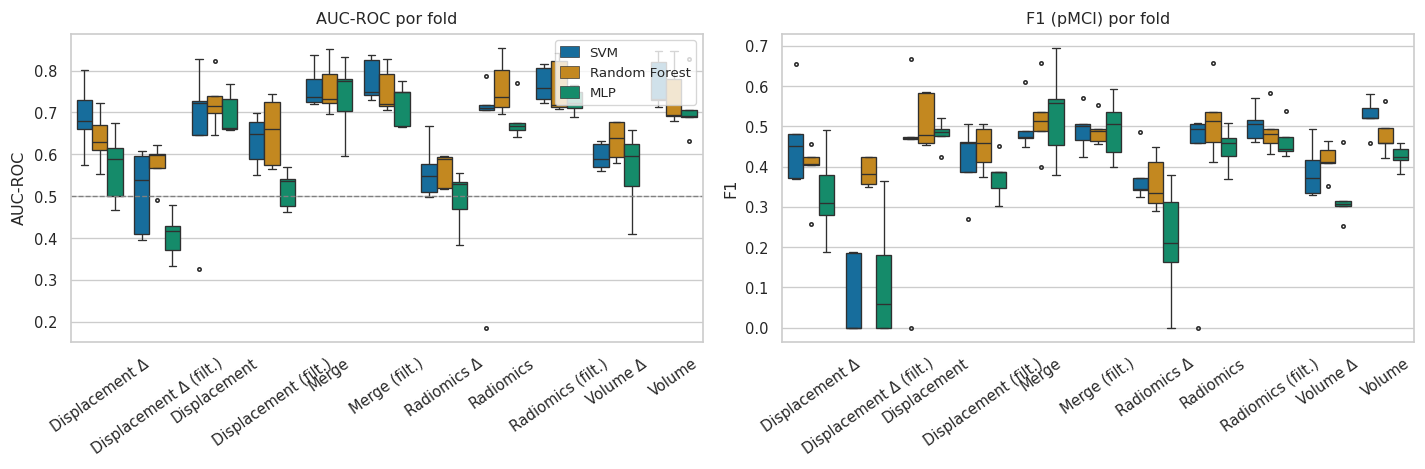

In [72]:
# ── Fig 5: Distribuição fold-a-fold (boxplot) ─────────────────────────────────

def plot_fold_boxplots(results: pd.DataFrame) -> plt.Figure | None:
    if results.empty:
        print("Sem arquivos ablation_results_*.csv — boxplot ignorado.")
        return None

    exp_order = (
        results.drop_duplicates("experiment_id")
        .sort_values(["family", "temporal", "filtered"])["label"]
        .tolist()
    )
    results = results.copy()
    results["label"] = pd.Categorical(results["label"], categories=exp_order, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(
        data=results, x="label", y="auc", hue="model_key",
        hue_order=MODEL_ORDER, palette=MODEL_COLORS,
        linewidth=0.8, fliersize=2, ax=axes[0], legend=False,
    )
    axes[0].axhline(CHANCE, color="gray", ls="--", lw=0.8)
    axes[0].set_title("AUC-ROC por fold")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("AUC-ROC")
    axes[0].tick_params(axis="x", rotation=35)
    model_legend(axes[0], loc="upper right", fontsize=8)

    sns.boxplot(
        data=results, x="label", y="f1_pMCI", hue="model_key",
        hue_order=MODEL_ORDER, palette=MODEL_COLORS,
        linewidth=0.8, fliersize=2, ax=axes[1], legend=False,
    )
    axes[1].set_title("F1 (pMCI) por fold")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("F1")
    axes[1].tick_params(axis="x", rotation=35)

    fig.tight_layout()
    return fig


fig5 = plot_fold_boxplots(results)
if fig5:
    save_fig(fig5, "fig05_fold_boxplots")
    plt.show()

Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig06_multi_metric_top5.[png|pdf]


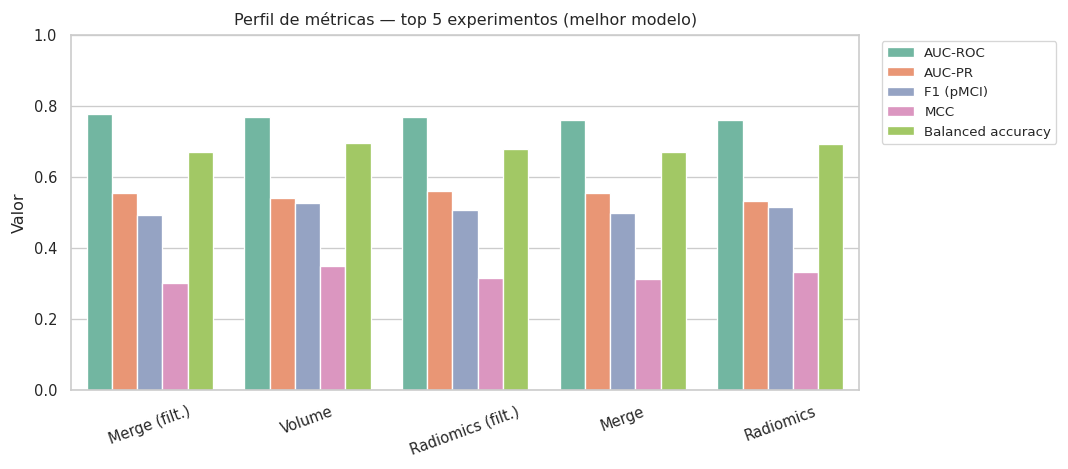

In [73]:
# ── Fig 6: Métricas múltiplas — top experimentos ──────────────────────────────

def plot_multi_metric(summary: pd.DataFrame, top_n: int = 5) -> plt.Figure:
    best = best_per_experiment(summary).nlargest(top_n, "auc_mean")
    metrics_show = ["auc_mean", "auc_pr_mean", "f1_pMCI_mean", "mcc_mean", "bal_acc_mean"]
    labels_show = [METRIC_LABELS[m.replace("_mean", "")] for m in metrics_show]

    rows = []
    for _, r in best.iterrows():
        for m, lab in zip(metrics_show, labels_show):
            rows.append({
                "experimento": r["label"],
                "modelo": MODEL_LABELS[r["model_key"]],
                "métrica": lab,
                "valor": r[m],
            })
    long = pd.DataFrame(rows)
    long["experimento"] = pd.Categorical(
        long["experimento"], categories=best["label"].tolist(), ordered=True
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(
        data=long, x="experimento", y="valor", hue="métrica",
        palette="Set2", edgecolor="white", ax=ax,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Valor")
    ax.set_xlabel("")
    ax.set_title(f"Perfil de métricas — top {top_n} experimentos (melhor modelo)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    return fig


fig6 = plot_multi_metric(summary, top_n=5)
save_fig(fig6, "fig06_multi_metric_top5")
plt.show()

Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig07_sens_spec_tradeoff.[png|pdf]


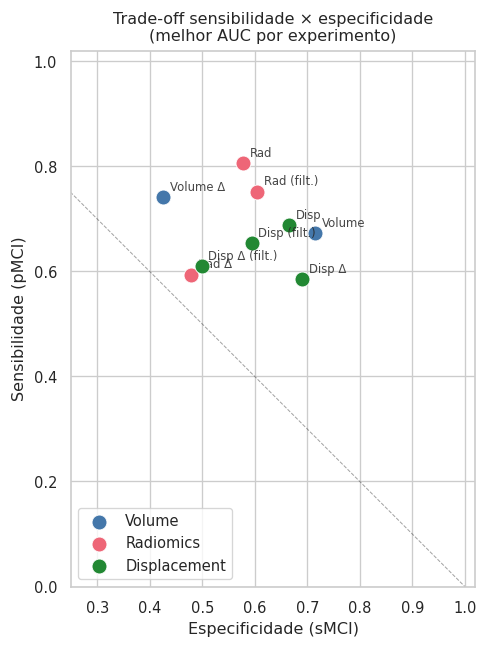

In [74]:
# ── Fig 7: Sensibilidade vs Especificidade (melhor modelo / experimento) ───────

def plot_sens_spec(summary: pd.DataFrame) -> plt.Figure:
    best = best_per_experiment(summary)

    fig, ax = plt.subplots(figsize=(6, 5.5))
    for family in FAMILY_ORDER:
        sub = best[best["family"] == family]
        ax.scatter(
            sub["spec_sMCI_mean"], sub["sens_pMCI_mean"],
            s=80, c=PALETTE_FAMILY[family], label=FAMILY_LABELS[family],
            edgecolors="white", linewidths=0.5, zorder=3,
        )
        for _, r in sub.iterrows():
            ax.annotate(
                r["label"].replace("Radiomics", "Rad").replace("Displacement", "Disp"),
                (r["spec_sMCI_mean"], r["sens_pMCI_mean"]),
                textcoords="offset points", xytext=(4, 4), fontsize=7, alpha=0.85,
            )

    ax.plot([0, 1], [1, 0], "k--", lw=0.6, alpha=0.4)
    ax.set_xlabel("Especificidade (sMCI)")
    ax.set_ylabel("Sensibilidade (pMCI)")
    ax.set_xlim(0.25, 1.02)
    ax.set_ylim(0, 1.02)
    ax.set_title("Trade-off sensibilidade × especificidade\n(melhor AUC por experimento)")
    ax.legend(loc="lower left", frameon=True)
    ax.set_aspect("equal")
    fig.tight_layout()
    return fig


fig7 = plot_sens_spec(summary)
save_fig(fig7, "fig07_sens_spec_tradeoff")
plt.show()

Salvo: csvs/abordagem_4_sMCI_pMCI_extremos/figures/fig08_filter_effect.[png|pdf]


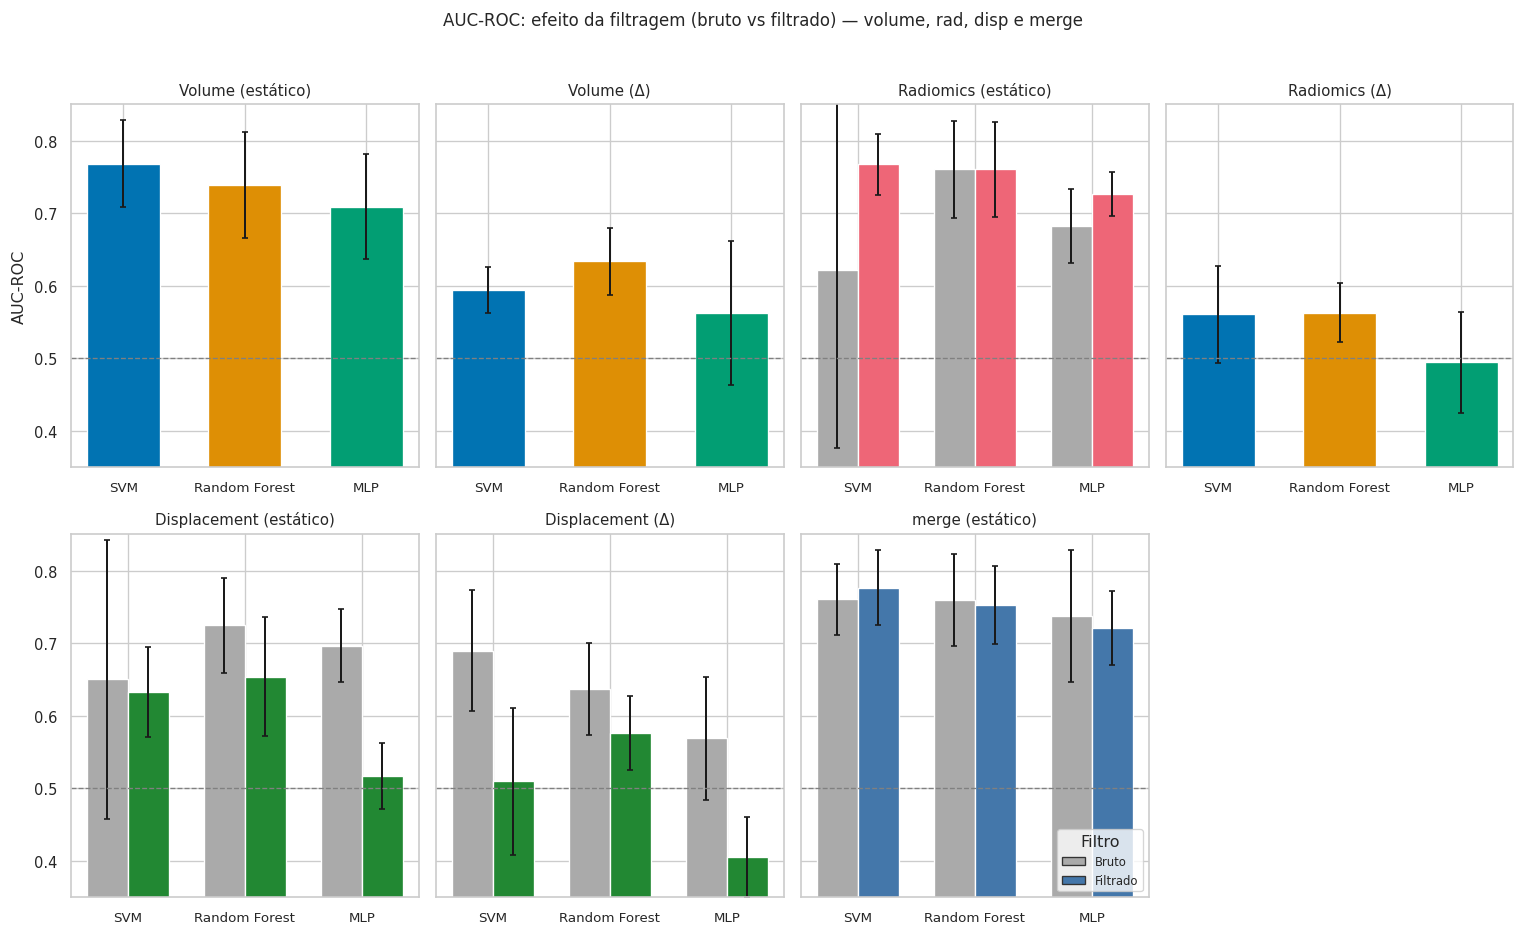

In [77]:
# ── Fig 8: Efeito do filtro + volume / radiomics Δ ────────────────────────────

def _summary_slice(
    summary: pd.DataFrame, family: str, temporal: str, *, filtered: bool
) -> pd.DataFrame:
    return summary[
        (summary["family"] == family)
        & (summary["temporal"] == temporal)
        & (summary["filtered"] == filtered)
    ]


# Ordem dos painéis: bruto vs filtrado quando ambos existem; senão só bruto
FIG8_PANELS = [
    {"family": "volume", "temporal": "static"},
    {"family": "volume", "temporal": "delta"},
    {"family": "rad", "temporal": "static"},
    {"family": "rad", "temporal": "delta"},      # rad Δ filtrado se existir onlyrad_delta_filtered
    {"family": "disp", "temporal": "static"},
    {"family": "disp", "temporal": "delta"},
    {"family": "merge", "temporal": "static"},   # merge + merge_filtered
    {"family": "merge", "temporal": "delta"},    # omitido se CSV não existir
]


def plot_filter_effect(summary: pd.DataFrame) -> plt.Figure | None:
    panels: list[tuple] = []
    for cfg in FIG8_PANELS:
        raw = _summary_slice(summary, cfg["family"], cfg["temporal"], filtered=False)
        if raw.empty:
            continue
        filt = _summary_slice(summary, cfg["family"], cfg["temporal"], filtered=True)
        if filt.empty:
            panels.append(({**cfg, "kind": "single"}, raw, None))
        else:
            panels.append(({**cfg, "kind": "compare"}, raw, filt))

    if not panels:
        print("Nenhum painel disponível para fig08.")
        return None

    n_panels = len(panels)
    ncols = min(4, n_panels)
    nrows = (n_panels + ncols - 1) // ncols
    fig, axes_grid = plt.subplots(
        nrows, ncols, figsize=(3.2 * ncols, 3.8 * nrows), sharey=True,
    )
    axes = np.atleast_1d(axes_grid).flatten()
    for ax in axes[n_panels:]:
        ax.set_visible(False)

    has_compare = False
    for ax, (cfg, raw, filt) in zip(axes[:n_panels], panels):
        family, temporal, kind = cfg["family"], cfg["temporal"], cfg["kind"]
        x = np.arange(len(MODEL_ORDER))
        tlab = "Δ" if temporal == "delta" else "estático"
        title = f"{FAMILY_LABELS.get(family, family)} ({tlab})"
        raw_m = raw.set_index("model_key").reindex(MODEL_ORDER)

        if kind == "compare":
            has_compare = True
            w = 0.35
            filt_m = filt.set_index("model_key").reindex(MODEL_ORDER)
            ax.bar(
                x - w / 2, raw_m["auc_mean"], w, yerr=raw_m["auc_std"],
                label="Bruto", color="#AAAAAA", capsize=2,
            )
            filt_color = PALETTE_FAMILY.get(family, "#4477AA")
            ax.bar(
                x + w / 2, filt_m["auc_mean"], w, yerr=filt_m["auc_std"],
                label="Filtrado", color=filt_color, capsize=2,
            )
        else:
            w = 0.6
            colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
            ax.bar(
                x, raw_m["auc_mean"], w, yerr=raw_m["auc_std"],
                color=colors, capsize=2, edgecolor="white",
            )

        ax.axhline(CHANCE, color="gray", ls="--", lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], fontsize=8)
        ax.set_title(title, fontsize=9)
        ax.set_ylim(0.35, 0.85)

    axes[0].set_ylabel("AUC-ROC")

    if has_compare:
        from matplotlib.patches import Patch
        filter_handles = [
            Patch(facecolor="#AAAAAA", edgecolor="#333333", label="Bruto"),
            Patch(facecolor="#4477AA", edgecolor="#333333", label="Filtrado"),
        ]
        axes[n_panels - 1].legend(
            handles=filter_handles, loc="lower right", fontsize=7, title="Filtro",
        )

    fig.suptitle(
        "AUC-ROC: efeito da filtragem (bruto vs filtrado) — volume, rad, disp e merge",
        y=1.02, fontsize=10,
    )
    fig.tight_layout()
    return fig


fig8 = plot_filter_effect(summary)
if fig8:
    save_fig(fig8, "fig08_filter_effect")
    plt.show()

## Resumo das figuras geradas

| Arquivo | Uso sugerido |
|---------|----------------|
| `fig01_heatmap_auc` | Visão geral — slide de resultados |
| `fig02_best_auc_per_experiment` | Ranking de experimentos (artigo: figura principal) |
| `fig03_models_per_experiment` | Comparação SVM / RF / MLP |
| `fig04_static_vs_delta` | Hipótese longitudinal |
| `fig05_fold_boxplots` | Variabilidade entre folds (robustez) |
| `fig06_multi_metric_top5` | Perfil completo dos melhores |
| `fig07_sens_spec_tradeoff` | Discussão clínica (trade-off) |
| `fig08_filter_effect` | Filtro bruto vs filtrado + volume e radiomics Δ |

**Tabelas:** `ablation_table_best_per_experiment.csv` e `.tex`

**Para o artigo:** use os PDFs em `figures/` (vetorial). Ajuste largura no LaTeX com `\includegraphics[width=\linewidth]{...}`.

**Para nova ablação:** basta rodar `ablation.ipynb` com novos nomes `ablation_summary_*.csv` — este notebook detecta automaticamente.